<a href="https://colab.research.google.com/github/shafiqul-cyber/Skill_Morph_Practice_from_Instrictor-/blob/Skill_Morph/Assignment_7_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, auc
)
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
print("Reading the real cancer dataset...")
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')

Reading the real cancer dataset...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import pandas as pd

# Load your dataset
df = pd.read_csv("/content/drive/MyDrive/datasets/CLASS_7/healthcare_dataset_stroke_data.csv")

# Display first 5 instances (rows)
print("=== Sample Instances ===")
print(df.head())

# Show number of instances and features
n_instances, n_features = df.shape
print("\nNumber of Instances (rows):", n_instances)
print("Number of Features (columns):", n_features)

# Display feature (column) names
print("\n=== Feature Names ===")
print(df.columns.tolist())

# Check data types and missing values
print("\n=== Dataset Info ===")
print(df.info())

# Show descriptive statistics
print("\n=== Summary Statistics ===")
print(df.describe())


=== Sample Instances ===
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  

Number of Instances (rows): 51

In [21]:
#additional code for checking missing values
print('\nCheck for missing values:')
print(df.isnull().sum())


Check for missing values:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [22]:
df_mean_filled = df.copy()
df_mean_filled = df_mean_filled.fillna(df_mean_filled.mean(numeric_only=True))
# Choose one to continue with (mean or median)
df = df_mean_filled  # or df_median_filled

# Verify missing values handled
print("✅ Missing values filled successfully!")
print(df.isnull().sum())

✅ Missing values filled successfully!
id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [23]:
print(df)

         id  gender   age  hypertension  heart_disease ever_married  \
0      9046    Male  67.0             0              1          Yes   
1     51676  Female  61.0             0              0          Yes   
2     31112    Male  80.0             0              1          Yes   
3     60182  Female  49.0             0              0          Yes   
4      1665  Female  79.0             1              0          Yes   
...     ...     ...   ...           ...            ...          ...   
5105  18234  Female  80.0             1              0          Yes   
5106  44873  Female  81.0             0              0          Yes   
5107  19723  Female  35.0             0              0          Yes   
5108  37544    Male  51.0             0              0          Yes   
5109  44679  Female  44.0             0              0          Yes   

          work_type Residence_type  avg_glucose_level        bmi  \
0           Private          Urban             228.69  36.600000   
1     Self-

In [24]:
# LabelEncoder converts categorical labels (like words) into numeric values so **ML models** can use them.
from sklearn.preprocessing import LabelEncoder

# For yes/no (2 categories only)
label_encoder = LabelEncoder()

# Convert 'mainroad' column
df['gender_encoded'] = label_encoder.fit_transform(df['gender'])
print("\nAfter Label Encoding 'mainroad':")
print(df[['gender', 'gender_encoded']])
# Female = 0, Male = 1
# Convert 'ever_maried' column
df['ever_married_encoded'] = label_encoder.fit_transform(df['ever_married'])
print("\nAfter Label Encoding 'mainroad':")
print(df[['ever_married', 'ever_married_encoded']])
# no = 0, yes = 1
# Convert 'ever_maried' column
df['work_type_encoded'] = label_encoder.fit_transform(df['work_type'])
print("\nAfter Label Encoding 'mainroad':")
print(df[['work_type', 'work_type_encoded']])
# no = 0, yes = 1

# Convert 'ever_maried' column
df['Residence_type_encoded'] = label_encoder.fit_transform(df['Residence_type'])
print("\nAfter Label Encoding 'mainroad':")
print(df[['Residence_type', 'Residence_type_encoded']])
# no = Rural, Urban = 1
# Convert 'ever_maried' column
df['smoking_status_encoded'] = label_encoder.fit_transform(df['smoking_status'])
print("\nAfter Label Encoding 'mainroad':")
print(df[['smoking_status', 'smoking_status_encoded']])
# no = Rural, Urban = 1



After Label Encoding 'mainroad':
      gender  gender_encoded
0       Male               1
1     Female               0
2       Male               1
3     Female               0
4     Female               0
...      ...             ...
5105  Female               0
5106  Female               0
5107  Female               0
5108    Male               1
5109  Female               0

[5110 rows x 2 columns]

After Label Encoding 'mainroad':
     ever_married  ever_married_encoded
0             Yes                     1
1             Yes                     1
2             Yes                     1
3             Yes                     1
4             Yes                     1
...           ...                   ...
5105          Yes                     1
5106          Yes                     1
5107          Yes                     1
5108          Yes                     1
5109          Yes                     1

[5110 rows x 2 columns]

After Label Encoding 'mainroad':
          work_type 

In [25]:
print(df)

         id  gender   age  hypertension  heart_disease ever_married  \
0      9046    Male  67.0             0              1          Yes   
1     51676  Female  61.0             0              0          Yes   
2     31112    Male  80.0             0              1          Yes   
3     60182  Female  49.0             0              0          Yes   
4      1665  Female  79.0             1              0          Yes   
...     ...     ...   ...           ...            ...          ...   
5105  18234  Female  80.0             1              0          Yes   
5106  44873  Female  81.0             0              0          Yes   
5107  19723  Female  35.0             0              0          Yes   
5108  37544    Male  51.0             0              0          Yes   
5109  44679  Female  44.0             0              0          Yes   

          work_type Residence_type  avg_glucose_level        bmi  \
0           Private          Urban             228.69  36.600000   
1     Self-

In [26]:
print(df.columns.tolist())

['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke', 'gender_encoded', 'ever_married_encoded', 'work_type_encoded', 'Residence_type_encoded', 'smoking_status_encoded']


In [27]:
# Drop columns
df = df.drop(['gender', 'ever_married','work_type','Residence_type','smoking_status'], axis=1)

In [28]:
print(df.columns.tolist())

['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke', 'gender_encoded', 'ever_married_encoded', 'work_type_encoded', 'Residence_type_encoded', 'smoking_status_encoded']


In [29]:
# Split into Train and Test
# TODO: Split - 80% train, 20% test
# Separate input (X) and output (y)
X = df.drop('stroke', axis=1)  # Everything except stroke
y = df['stroke']                # Only stroke

print("X has all  information except house price")
print("y has price (1 column)")

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% for test
    random_state=42   # Same result every time
)

print(f"\nWe will train with: {len(X_train)} ")
print(f"We will test with: {len(X_test)} ")

X has all  information except house price
y has price (1 column)

We will train with: 4088 
We will test with: 1022 


In [30]:
from imblearn.over_sampling import SMOTE
# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Check results
print("✅ Before SMOTE:")
print(y_train.value_counts())
print("\n✅ After SMOTE:")
print(y_train_res.value_counts())

# Optional: show shapes
print(f"\nOriginal training shape: {X_train.shape}")
print(f"Resampled training shape: {X_train_res.shape}")

✅ Before SMOTE:
stroke
0    3901
1     187
Name: count, dtype: int64

✅ After SMOTE:
stroke
0    3901
1    3901
Name: count, dtype: int64

Original training shape: (4088, 11)
Resampled training shape: (7802, 11)


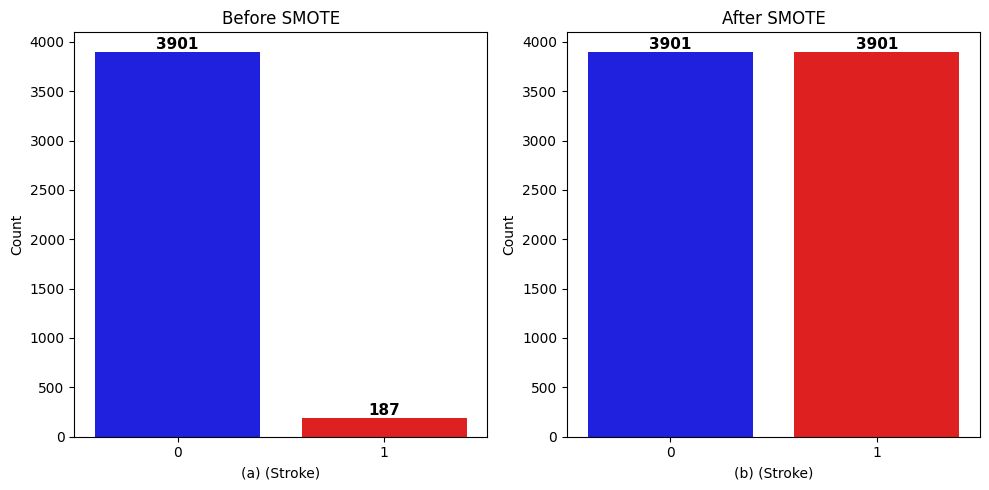

In [44]:
# ============================================================
# Class Distribution Before and After SMOTE (with counts)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Example: assuming you already have
# y_train  -> before SMOTE
# y_train_res -> after SMOTE

# Count classes
count_before = y_train.value_counts()
count_after = y_train_res.value_counts()

# Create side-by-side bar plots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# --- Before SMOTE ---
sns.countplot(x=y_train, palette=['blue', 'red'], ax=axes[0])
axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("(a) (Stroke)")
axes[0].set_ylabel("Count")

# Add text above bars
for p in axes[0].patches:
    axes[0].annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )



# --- After SMOTE ---
sns.countplot(x=y_train_res, palette=['blue', 'red'], ax=axes[1])
axes[1].set_title("After SMOTE")
axes[1].set_xlabel("(b) (Stroke)")
axes[1].set_ylabel("Count")

# Add text above bars
for p in axes[1].patches:
    axes[1].annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )



plt.tight_layout()
plt.savefig('/content/drive/MyDrive/datasets/CLASS_7/Assignment_Submission_Results/SMOTE.png',
            dpi=300, bbox_inches='tight')
plt.show()


In [31]:
# ============================================================
# STEP — Standardize Features using StandardScaler
# ============================================================

from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform both train & test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Standardization complete!")
print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")


✅ Standardization complete!
Training set shape: (4088, 11)
Test set shape: (1022, 11)


In [32]:
# ============================================================
# STEP — Apply Decision Tree Model
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Initialize the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5, criterion='gini')

# Train the model
dt_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = dt_model.predict(X_test_scaled)

# ============================================================
# STEP — Evaluate Model Performance
# ============================================================

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("✅ Model Evaluation Results:")
print("-----------------------------------")
print(f"Accuracy  : {acc*100:.2f}%")
print(f"Precision : {prec*100:.2f}%")
print(f"Recall    : {rec*100:.2f}%")
print(f"F1-Score  : {f1*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Optional — Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


✅ Model Evaluation Results:
-----------------------------------
Accuracy  : 93.54%
Precision : 33.33%
Recall    : 6.45%
F1-Score  : 10.81%

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97       960
           1       0.33      0.06      0.11        62

    accuracy                           0.94      1022
   macro avg       0.64      0.53      0.54      1022
weighted avg       0.91      0.94      0.91      1022

Confusion Matrix:
[[952   8]
 [ 58   4]]


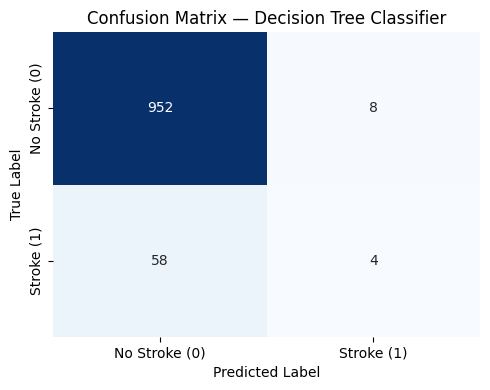

✅ Confusion Matrix saved to Google Drive as 'confusion_matrix_DT.png'


In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create and save Confusion Matrix plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Stroke (0)', 'Stroke (1)'],
            yticklabels=['No Stroke (0)', 'Stroke (1)'])
plt.title("Confusion Matrix — Decision Tree Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

# Save to Google Drive
plt.savefig('/content/drive/MyDrive/datasets/CLASS_7/Assignment_Submission_Results/confusion_matrix_DT.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Confusion Matrix saved to Google Drive as 'confusion_matrix_DT.png'")


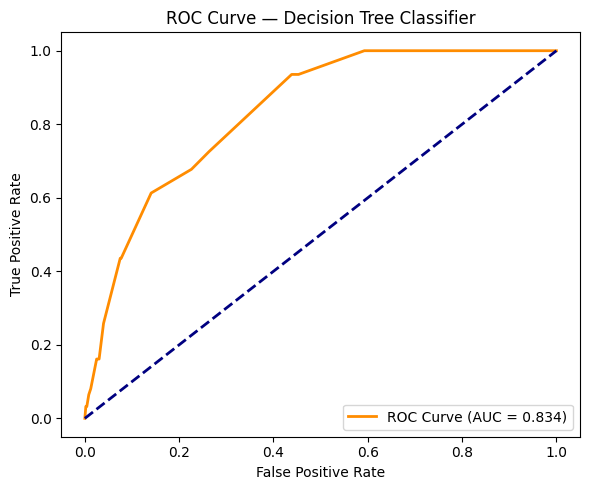

✅ ROC Curve saved to Google Drive as 'roc_curve_DT.png'


In [47]:
from sklearn.metrics import roc_curve, roc_auc_score

# ROC Curve
y_prob = dt_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Decision Tree Classifier')
plt.legend(loc='lower right')
plt.tight_layout()

# Save to Google Drive
plt.savefig('/content/drive/MyDrive/datasets/CLASS_7/Assignment_Submission_Results/roc_curve_DT.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ ROC Curve saved to Google Drive as 'roc_curve_DT.png'")
